# House Price Prediction
### End-to-End Machine Learning Project

**Author:** Shivanshu Tiwari
**Project:** Predicting residential house prices using regression-based Machine Learning models

---

## 1. Problem Statement
Real estate prices depend on a large number of interacting factors — size, location, age, amenities,
and neighbourhood quality. Buyers, sellers, and real-estate platforms need a reliable, data-driven way
to estimate a fair price for a property instead of relying purely on intuition or ad-hoc comparisons.

**Goal:** Build and evaluate regression models that predict the sale price of a house from its
structural and locational features, and identify which features drive price the most.

## 2. Dataset
This notebook uses a **synthetically generated housing dataset** (`house_price_data.csv`, created in
Section 3 below) that mimics the structure and statistical relationships found in real-world housing
datasets such as the Kaggle *House Prices* and *California Housing* datasets. It is generated with a
fixed random seed so the whole notebook is 100% reproducible offline, with no external downloads
required.

> **Using a real dataset instead:** If you would like to run this notebook on a real dataset (e.g. the
> [Kaggle House Prices - Ames Housing dataset](https://www.kaggle.com/c/house-prices-advanced-regression-techniques)
> or the California Housing dataset), simply replace the code in Section 3 with
> `df = pd.read_csv("your_file.csv")` and adjust the column names in Section 4 onward to match. The
> rest of the pipeline (EDA → preprocessing → modeling → evaluation → tuning) will work unchanged for
> any tabular housing dataset with a numeric target column.

## 3. Notebook Roadmap
1. Import Libraries
2. Load / Generate Dataset
3. Exploratory Data Analysis (EDA)
4. Data Cleaning & Preprocessing
5. Feature Engineering & Train/Test Split
6. Model Building (multiple algorithms)
7. Model Evaluation & Comparison
8. Hyperparameter Tuning
9. Feature Importance
10. Final Model & Predictions
11. Save Model
12. Conclusion


## 1. Import Libraries

In [1]:
# Core libraries
import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing & model selection
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler

# Models
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

# Metrics
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Persistence
import joblib

# Settings
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (9, 5)
pd.set_option("display.max_columns", None)
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

print("Libraries imported successfully.")


Libraries imported successfully.


## 2. Load / Generate Dataset

We generate a realistic synthetic housing dataset of **2,000 properties**. Each feature is drawn from a
distribution typical of real housing data, and the target variable `Price` is constructed from a
weighted combination of the features plus random noise — mirroring how real house prices are driven by
a mix of measurable factors and market randomness.

*(To use a real dataset, replace this cell with `df = pd.read_csv("your_dataset.csv")`.)*


In [2]:
n_samples = 2000
rng = np.random.default_rng(RANDOM_STATE)

# --- Structural features ---
area_sqft            = rng.normal(1800, 650, n_samples).clip(400, 6000)
bedrooms             = rng.integers(1, 7, n_samples)
bathrooms            = rng.integers(1, 5, n_samples)
stories              = rng.integers(1, 4, n_samples)
house_age_years      = rng.integers(0, 60, n_samples)
garage_spaces        = rng.integers(0, 4, n_samples)

# --- Locational / quality features ---
distance_to_city_km  = rng.exponential(8, n_samples).clip(0.2, 45)
school_rating        = rng.integers(1, 11, n_samples)          # 1 (poor) - 10 (excellent)
crime_rate_index     = rng.normal(50, 20, n_samples).clip(1, 100)  # lower is safer
has_pool             = rng.choice([0, 1], n_samples, p=[0.8, 0.2])
has_basement         = rng.choice([0, 1], n_samples, p=[0.6, 0.4])
furnishing_status    = rng.choice(["Unfurnished", "Semi-Furnished", "Furnished"],
                                   n_samples, p=[0.45, 0.35, 0.20])
location_type        = rng.choice(["Urban", "Suburban", "Rural"],
                                   n_samples, p=[0.4, 0.4, 0.2])

# --- Price generation (ground-truth relationship + noise) ---
location_premium = pd.Series(location_type).map({"Urban": 35000, "Suburban": 12000, "Rural": -8000}).values
furnishing_premium = pd.Series(furnishing_status).map(
    {"Furnished": 15000, "Semi-Furnished": 6000, "Unfurnished": 0}).values

base_price = (
      area_sqft * 120
    + bedrooms * 9000
    + bathrooms * 7000
    + stories * 5000
    - house_age_years * 900
    + garage_spaces * 6000
    - distance_to_city_km * 1500
    + school_rating * 4000
    - crime_rate_index * 500
    + has_pool * 18000
    + has_basement * 10000
    + location_premium
    + furnishing_premium
    + 40000  # base offset
)

noise = rng.normal(0, 25000, n_samples)
price = (base_price + noise).clip(35000, None).round(-2)  # no negative/unrealistic prices

df = pd.DataFrame({
    "Area_sqft": area_sqft.round(0),
    "Bedrooms": bedrooms,
    "Bathrooms": bathrooms,
    "Stories": stories,
    "House_Age_Years": house_age_years,
    "Garage_Spaces": garage_spaces,
    "Distance_to_City_km": distance_to_city_km.round(2),
    "School_Rating": school_rating,
    "Crime_Rate_Index": crime_rate_index.round(1),
    "Has_Pool": has_pool,
    "Has_Basement": has_basement,
    "Furnishing_Status": furnishing_status,
    "Location_Type": location_type,
    "Price": price
})

# Inject a small % of realistic missing values (as real-world data usually has)
for col in ["Area_sqft", "School_Rating", "Furnishing_Status"]:
    missing_idx = rng.choice(df.index, size=int(0.02 * n_samples), replace=False)
    df.loc[missing_idx, col] = np.nan

df.to_csv("house_price_data.csv", index=False)
print("Dataset shape:", df.shape)
df.head()


Dataset shape: (2000, 14)


,Area_sqft,Bedrooms,Bathrooms,Stories,House_Age_Years,Garage_Spaces,Distance_to_City_km,School_Rating,Crime_Rate_Index,Has_Pool,Has_Basement,Furnishing_Status,Location_Type,Price
0,NaN,5,1,2,9,1,2.98,3.0,34.2,1,1,Unfurnished,Urban,454600.0
1,1124.0,1,4,1,59,1,8.48,8.0,54.6,0,0,Semi-Furnished,Urban,253500.0
2,2288.0,3,1,2,35,3,3.70,6.0,63.6,0,0,Semi-Furnished,Suburban,364000.0
3,2411.0,3,2,1,13,1,4.93,8.0,40.2,0,1,Furnished,Urban,467100.0
4,532.0,6,2,2,48,2,11.40,10.0,66.5,1,1,Unfurnished,Suburban,212900.0


## 3. Exploratory Data Analysis (EDA)

### 3.1 Basic Info & Summary Statistics

In [3]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 14 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Area_sqft            1960 non-null   float64
 1   Bedrooms             2000 non-null   int64  
 2   Bathrooms            2000 non-null   int64  
 3   Stories              2000 non-null   int64  
 4   House_Age_Years      2000 non-null   int64  
 5   Garage_Spaces        2000 non-null   int64  
 6   Distance_to_City_km  2000 non-null   float64
 7   School_Rating        1960 non-null   float64
 8   Crime_Rate_Index     2000 non-null   float64
 9   Has_Pool             2000 non-null   int64  
 10  Has_Basement         2000 non-null   int64  
 11  Furnishing_Status    1960 non-null   str    
 12  Location_Type        2000 non-null   str    
 13  Price                2000 non-null   float64
dtypes: float64(5), int64(7), str(2)
memory usage: 218.9 KB


In [4]:
df.describe(include="all").T


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Area_sqft,1960.0,NaN,NaN,NaN,1768.017857,641.042779,400.0,1329.0,1785.5,2192.0,3866.0
Bedrooms,2000.0,NaN,NaN,NaN,3.4755,1.704069,1.0,2.0,3.0,5.0,6.0
Bathrooms,2000.0,NaN,NaN,NaN,2.451,1.116791,1.0,1.0,2.0,3.0,4.0
Stories,2000.0,NaN,NaN,NaN,1.9985,0.810448,1.0,1.0,2.0,3.0,3.0
House_Age_Years,2000.0,NaN,NaN,NaN,29.7395,17.255333,0.0,15.0,30.0,45.0,59.0
Garage_Spaces,2000.0,NaN,NaN,NaN,1.4605,1.108176,0.0,0.0,1.0,2.0,3.0
Distance_to_City_km,2000.0,NaN,NaN,NaN,7.911745,7.872606,0.2,2.36,5.395,10.86,45.0
School_Rating,1960.0,NaN,NaN,NaN,5.425,2.896458,1.0,3.0,5.0,8.0,10.0
Crime_Rate_Index,2000.0,NaN,NaN,NaN,49.6099,19.763151,1.0,35.975,49.25,63.3,100.0
Has_Pool,2000.0,NaN,NaN,NaN,0.1875,0.39041,0.0,0.0,0.0,0.0,1.0


### 3.2 Missing Values

In [5]:
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_summary = pd.DataFrame({"Missing Count": missing, "Missing %": missing_pct})
missing_summary[missing_summary["Missing Count"] > 0]


,Missing Count,Missing %
Area_sqft,40,2.0
School_Rating,40,2.0
Furnishing_Status,40,2.0


### 3.3 Target Variable Distribution

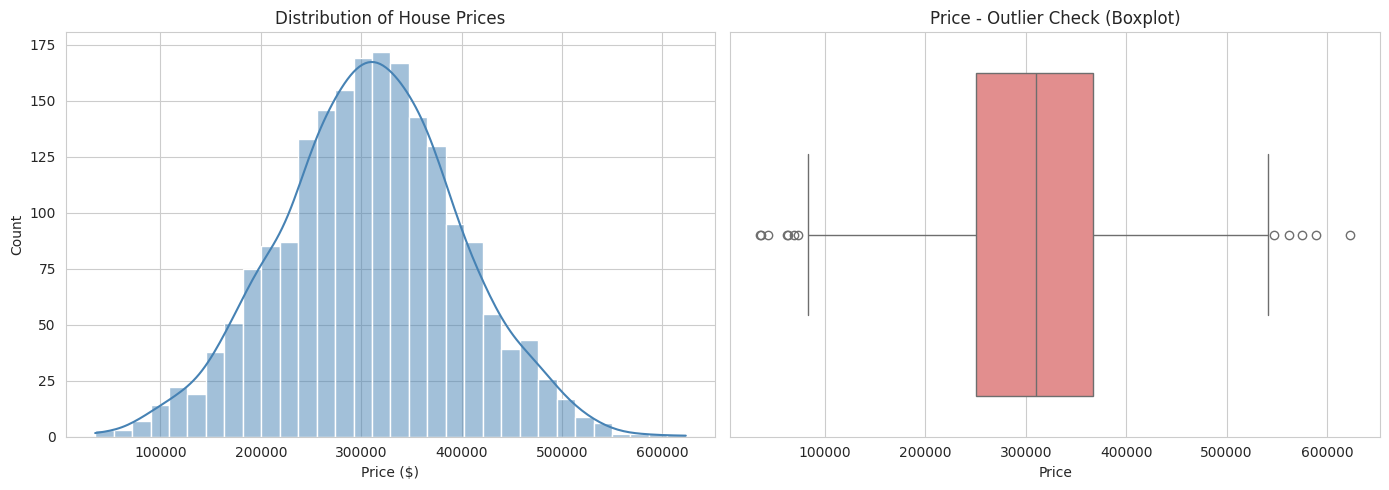

Price skewness: -0.021


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.histplot(df["Price"], kde=True, ax=axes[0], color="steelblue")
axes[0].set_title("Distribution of House Prices")
axes[0].set_xlabel("Price ($)")

sns.boxplot(x=df["Price"], ax=axes[1], color="lightcoral")
axes[1].set_title("Price - Outlier Check (Boxplot)")
plt.tight_layout()
plt.show()

print(f"Price skewness: {df['Price'].skew():.3f}")


### 3.4 Numeric Feature Correlations

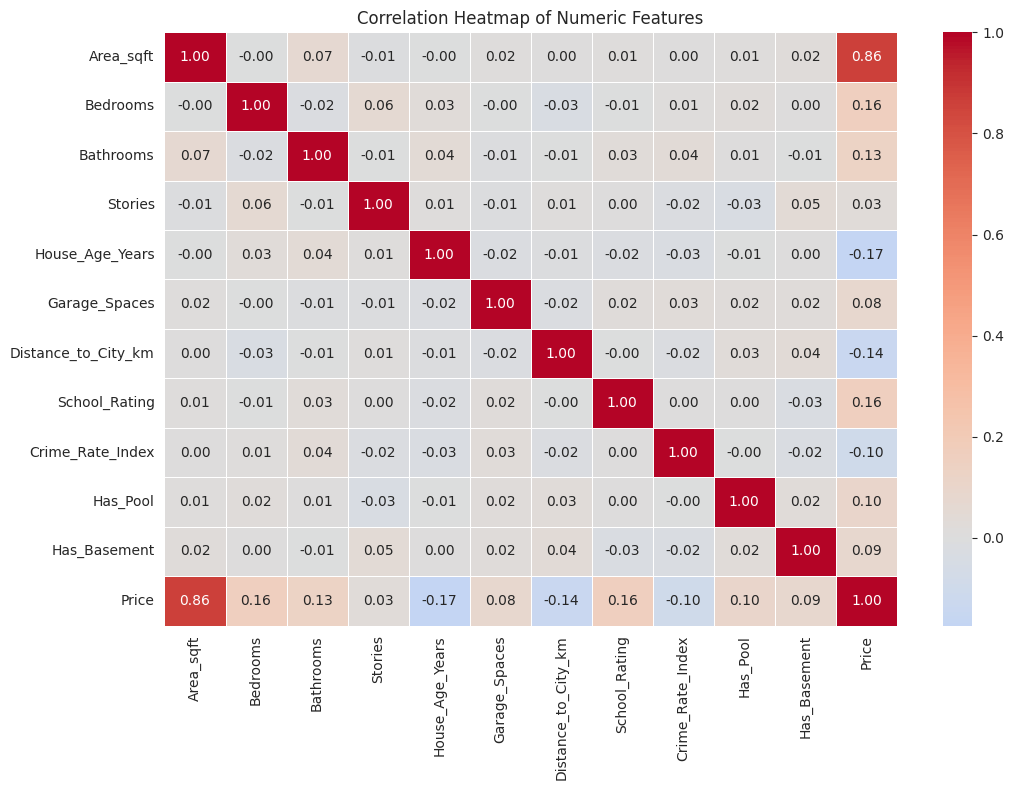

Top correlations with Price:
Price                  1.000000
Area_sqft              0.864939
Bedrooms               0.163827
School_Rating          0.157524
Bathrooms              0.130694
Has_Pool               0.099942
Has_Basement           0.085857
Garage_Spaces          0.082045
Stories                0.026094
Crime_Rate_Index      -0.097086
Distance_to_City_km   -0.139086
House_Age_Years       -0.173445
Name: Price, dtype: float64


In [7]:
numeric_df = df.select_dtypes(include=[np.number])
corr = numeric_df.corr()

plt.figure(figsize=(11, 8))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, linewidths=0.5)
plt.title("Correlation Heatmap of Numeric Features")
plt.tight_layout()
plt.show()

print("Top correlations with Price:")
print(corr["Price"].sort_values(ascending=False))


### 3.5 Relationship Between Key Features and Price

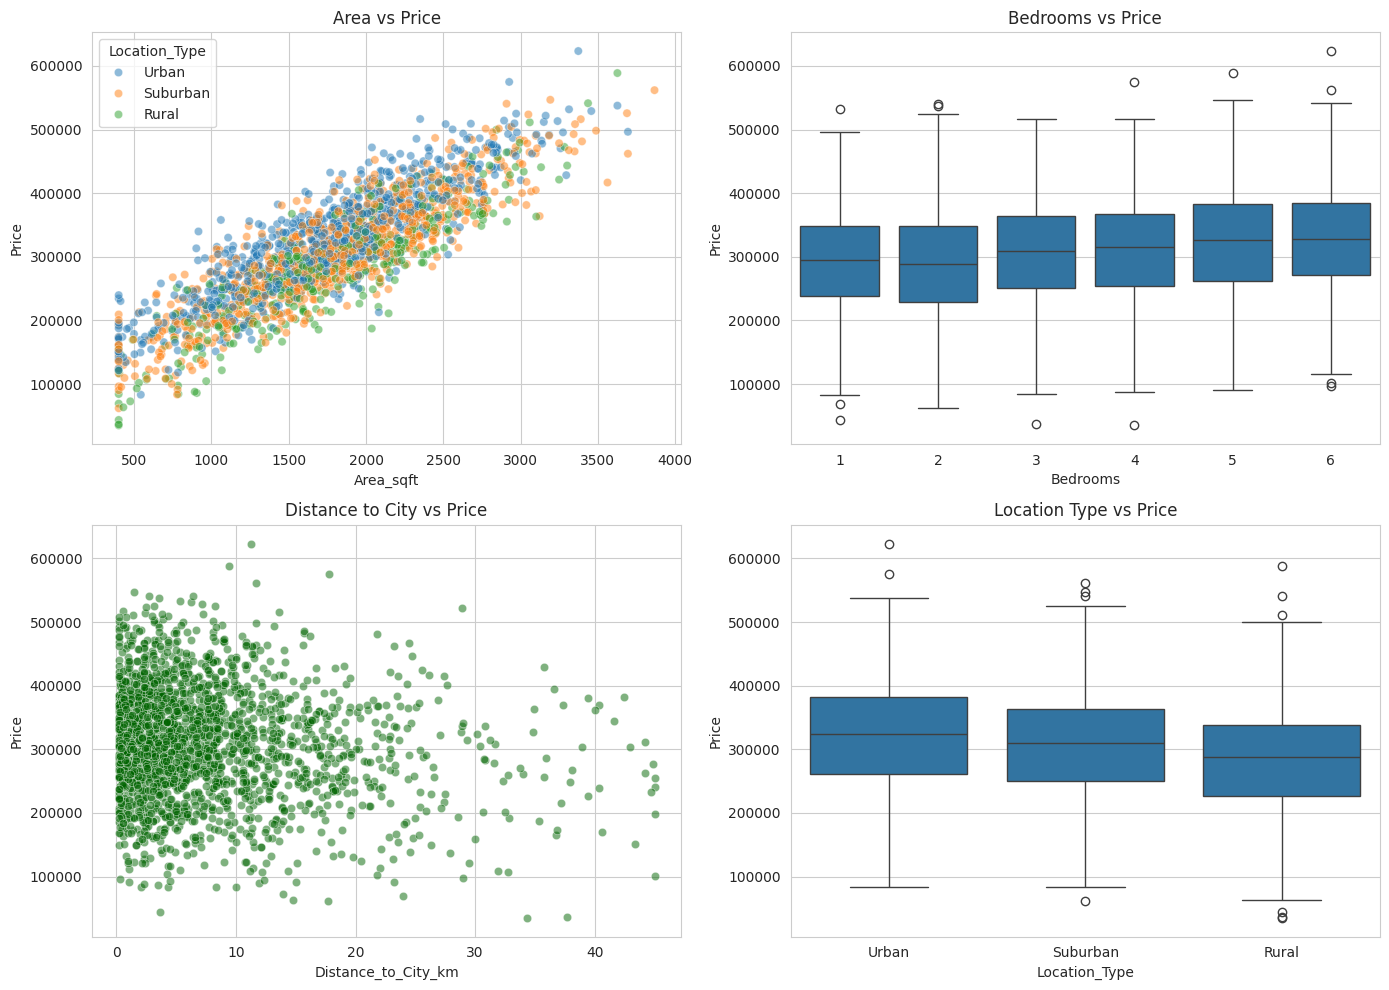

In [8]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

sns.scatterplot(data=df, x="Area_sqft", y="Price", hue="Location_Type", alpha=0.5, ax=axes[0, 0])
axes[0, 0].set_title("Area vs Price")

sns.boxplot(data=df, x="Bedrooms", y="Price", ax=axes[0, 1])
axes[0, 1].set_title("Bedrooms vs Price")

sns.scatterplot(data=df, x="Distance_to_City_km", y="Price", alpha=0.5, ax=axes[1, 0], color="darkgreen")
axes[1, 0].set_title("Distance to City vs Price")

sns.boxplot(data=df, x="Location_Type", y="Price", ax=axes[1, 1])
axes[1, 1].set_title("Location Type vs Price")

plt.tight_layout()
plt.show()


### 3.6 Categorical Feature Distributions

/tmp/ipykernel_149/2472102086.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x="Furnishing_Status", ax=axes[0], palette="viridis")
/tmp/ipykernel_149/2472102086.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x="Location_Type", ax=axes[1], palette="magma")


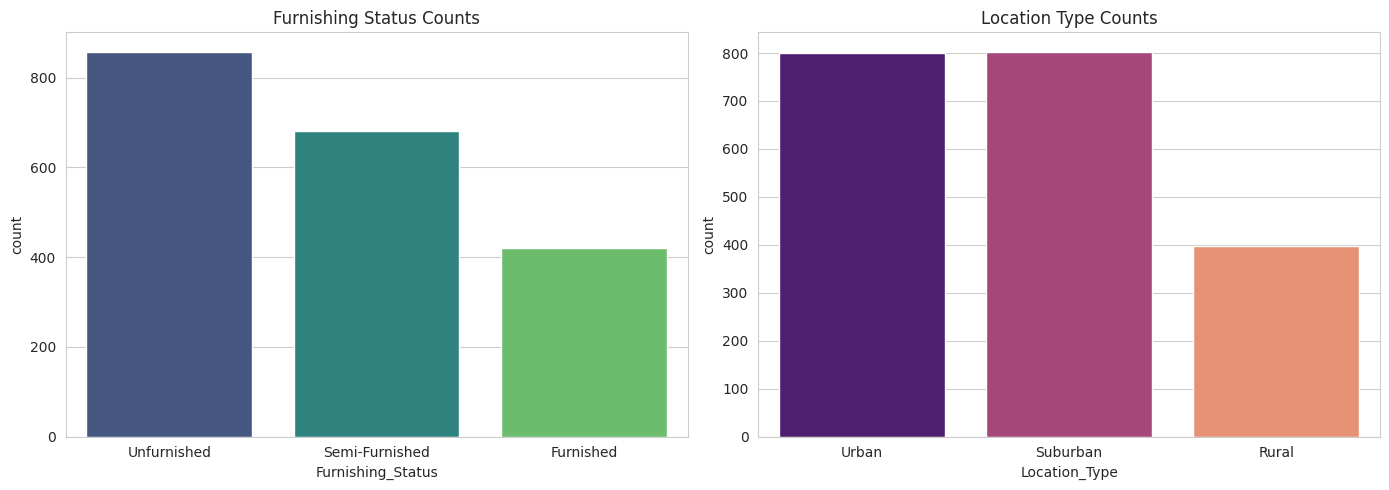

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.countplot(data=df, x="Furnishing_Status", ax=axes[0], palette="viridis")
axes[0].set_title("Furnishing Status Counts")

sns.countplot(data=df, x="Location_Type", ax=axes[1], palette="magma")
axes[1].set_title("Location Type Counts")
plt.tight_layout()
plt.show()


## 4. Data Cleaning & Preprocessing

Steps performed:
1. Impute missing numeric values with the **median** (robust to outliers).
2. Impute missing categorical values with the **mode**.
3. Encode categorical variables using **one-hot encoding**.
4. Check and cap extreme outliers using the IQR method (kept mild here since the data is synthetic).


In [10]:
df_clean = df.copy()

# 4.1 Impute missing values
num_cols = df_clean.select_dtypes(include=[np.number]).columns.drop("Price")
cat_cols = df_clean.select_dtypes(include="object").columns

for col in num_cols:
    if df_clean[col].isnull().any():
        df_clean[col] = df_clean[col].fillna(df_clean[col].median())

for col in cat_cols:
    if df_clean[col].isnull().any():
        df_clean[col] = df_clean[col].fillna(df_clean[col].mode()[0])

print("Remaining missing values:", df_clean.isnull().sum().sum())


Remaining missing values: 0


/tmp/ipykernel_149/983293816.py:5: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = df_clean.select_dtypes(include="object").columns


In [11]:
# 4.2 Outlier check on Price using IQR
Q1, Q3 = df_clean["Price"].quantile([0.25, 0.75])
IQR = Q3 - Q1
lower, upper = Q1 - 1.5 * IQR, Q3 + 1.5 * IQR
outliers = df_clean[(df_clean["Price"] < lower) | (df_clean["Price"] > upper)]
print(f"Number of price outliers (IQR method): {len(outliers)} ({len(outliers)/len(df_clean)*100:.2f}%)")

# Cap outliers rather than dropping rows, to preserve information
df_clean["Price"] = df_clean["Price"].clip(lower, upper)


Number of price outliers (IQR method): 12 (0.60%)


In [12]:
# 4.3 One-hot encode categorical columns
df_encoded = pd.get_dummies(df_clean, columns=list(cat_cols), drop_first=True)
print("Shape after encoding:", df_encoded.shape)
df_encoded.head()


Shape after encoding: (2000, 16)


,Area_sqft,Bedrooms,Bathrooms,Stories,House_Age_Years,Garage_Spaces,Distance_to_City_km,School_Rating,Crime_Rate_Index,Has_Pool,Has_Basement,Price,Furnishing_Status_Semi-Furnished,Furnishing_Status_Unfurnished,Location_Type_Suburban,Location_Type_Urban
0,1785.5,5,1,2,9,1,2.98,3.0,34.2,1,1,454600.0,False,True,False,True
1,1124.0,1,4,1,59,1,8.48,8.0,54.6,0,0,253500.0,True,False,False,True
2,2288.0,3,1,2,35,3,3.70,6.0,63.6,0,0,364000.0,True,False,True,False
3,2411.0,3,2,1,13,1,4.93,8.0,40.2,0,1,467100.0,False,False,False,True
4,532.0,6,2,2,48,2,11.40,10.0,66.5,1,1,212900.0,False,True,True,False


## 5. Feature Engineering & Train/Test Split

A couple of simple engineered features are added, then the data is split into training (80%) and
test (20%) sets. Numeric features are scaled with `StandardScaler` — this mainly benefits the linear
models (Linear/Ridge/Lasso); tree-based models are scale-invariant but scaling does no harm.


In [13]:
# Simple engineered feature: price per sqft is NOT used as input (it leaks the target);
# instead we add a ratio-based feature that captures house "density"
df_encoded["Rooms_per_Story"] = (df_encoded["Bedrooms"] + df_encoded["Bathrooms"]) / df_encoded["Stories"]

X = df_encoded.drop(columns=["Price"])
y = df_encoded["Price"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE
)

print("Training set:", X_train.shape)
print("Test set:", X_test.shape)


Training set: (1600, 16)
Test set: (400, 16)


In [14]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns, index=X_train.index)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X_test.columns, index=X_test.index)


## 6. Model Building

We train and compare five regression models:
1. **Linear Regression** — simple baseline
2. **Ridge Regression** — L2-regularized linear model
3. **Lasso Regression** — L1-regularized linear model (feature selection effect)
4. **Decision Tree Regressor** — captures non-linear relationships
5. **Random Forest Regressor** — ensemble of trees, usually strong baseline
6. **Gradient Boosting Regressor** — sequential boosting ensemble, often the top performer


In [15]:
models = {
    "Linear Regression": LinearRegression(),
    "Ridge Regression": Ridge(alpha=1.0, random_state=RANDOM_STATE),
    "Lasso Regression": Lasso(alpha=100, random_state=RANDOM_STATE, max_iter=5000),
    "Decision Tree": DecisionTreeRegressor(max_depth=8, random_state=RANDOM_STATE),
    "Random Forest": RandomForestRegressor(n_estimators=200, max_depth=10, random_state=RANDOM_STATE, n_jobs=-1),
    "Gradient Boosting": GradientBoostingRegressor(n_estimators=200, max_depth=3, learning_rate=0.1, random_state=RANDOM_STATE),
}

# Linear-family models use scaled data; tree models can use either (we use unscaled for interpretability)
scaled_models = {"Linear Regression", "Ridge Regression", "Lasso Regression"}

results = []
trained_models = {}

for name, model in models.items():
    if name in scaled_models:
        model.fit(X_train_scaled, y_train)
        preds = model.predict(X_test_scaled)
        cv_scores = cross_val_score(model, X_train_scaled, y_train, cv=5, scoring="r2")
    else:
        model.fit(X_train, y_train)
        preds = model.predict(X_test)
        cv_scores = cross_val_score(model, X_train, y_train, cv=5, scoring="r2")

    mae = mean_absolute_error(y_test, preds)
    rmse = np.sqrt(mean_squared_error(y_test, preds))
    r2 = r2_score(y_test, preds)

    results.append({
        "Model": name,
        "MAE": mae,
        "RMSE": rmse,
        "R2 Score": r2,
        "CV R2 (mean)": cv_scores.mean(),
        "CV R2 (std)": cv_scores.std()
    })
    trained_models[name] = model

results_df = pd.DataFrame(results).sort_values("R2 Score", ascending=False).reset_index(drop=True)
results_df


,Model,MAE,RMSE,R2 Score,CV R2 (mean),CV R2 (std)
0,Lasso Regression,21474.950015,28292.370207,0.900958,0.896035,0.005648
1,Ridge Regression,21505.904876,28320.956820,0.900758,0.895978,0.005587
2,Linear Regression,21510.265429,28324.115196,0.900736,0.895967,0.005595
3,Gradient Boosting,22108.880525,29462.831598,0.892594,0.867267,0.006676
4,Random Forest,26297.968351,33825.829464,0.858428,0.823037,0.014018
5,Decision Tree,36192.920828,45978.998330,0.738424,0.659916,0.026607


## 7. Model Evaluation & Comparison

/tmp/ipykernel_149/1480094303.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=results_df, x="R2 Score", y="Model", ax=axes[0], palette="crest")
/tmp/ipykernel_149/1480094303.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=results_df, x="RMSE", y="Model", ax=axes[1], palette="flare")


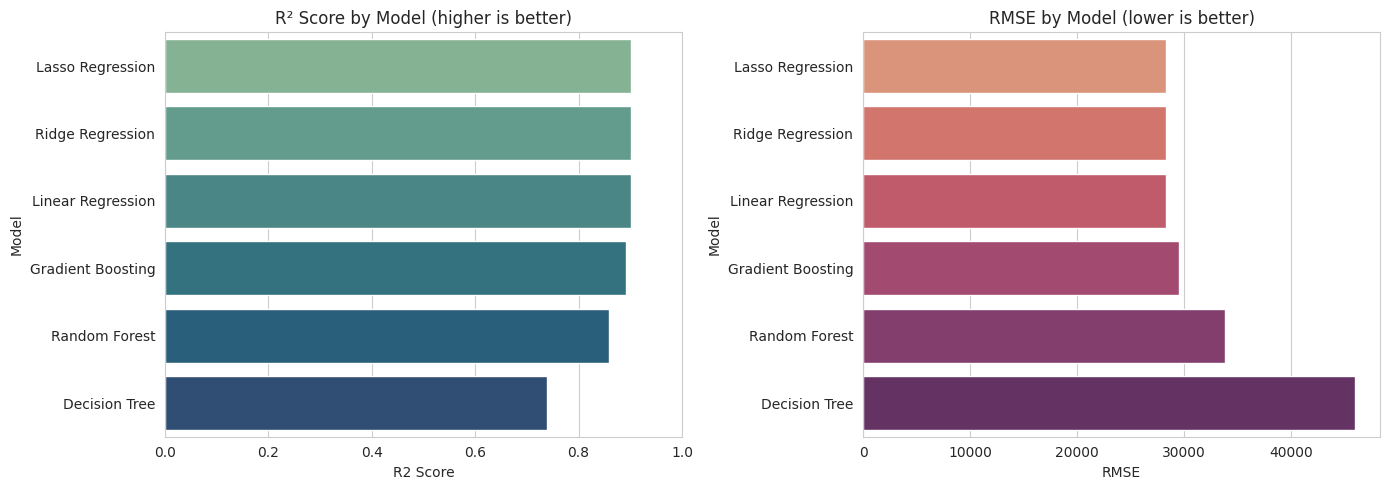

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.barplot(data=results_df, x="R2 Score", y="Model", ax=axes[0], palette="crest")
axes[0].set_title("R² Score by Model (higher is better)")
axes[0].set_xlim(0, 1)

sns.barplot(data=results_df, x="RMSE", y="Model", ax=axes[1], palette="flare")
axes[1].set_title("RMSE by Model (lower is better)")

plt.tight_layout()
plt.show()


In [17]:
best_model_name = results_df.iloc[0]["Model"]
best_model = trained_models[best_model_name]
print(f"Best performing model: {best_model_name}")
print(results_df.iloc[0])


Best performing model: Lasso Regression
Model           Lasso Regression
MAE                 21474.950015
RMSE                28292.370207
R2 Score                0.900958
CV R2 (mean)            0.896035
CV R2 (std)             0.005648
Name: 0, dtype: object


### 7.1 Actual vs Predicted (Best Model)

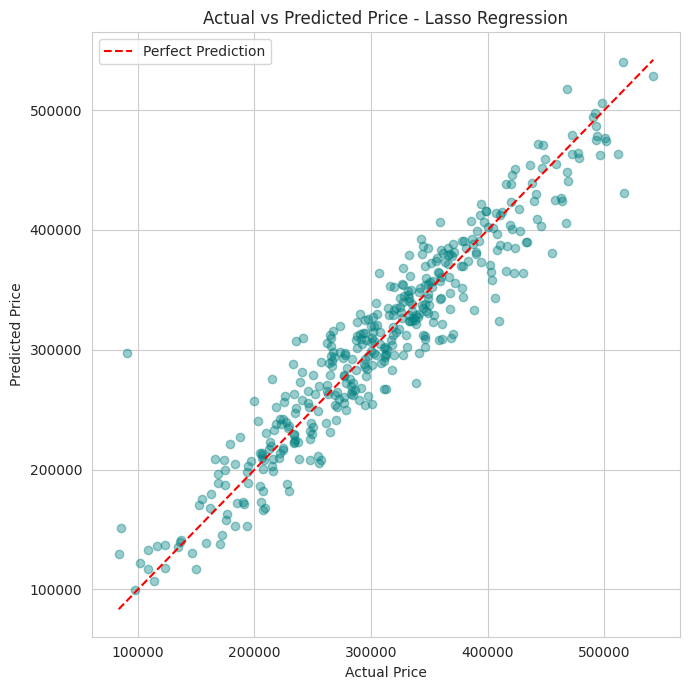

In [18]:
if best_model_name in scaled_models:
    best_preds = best_model.predict(X_test_scaled)
else:
    best_preds = best_model.predict(X_test)

plt.figure(figsize=(7, 7))
plt.scatter(y_test, best_preds, alpha=0.4, color="teal")
lims = [min(y_test.min(), best_preds.min()), max(y_test.max(), best_preds.max())]
plt.plot(lims, lims, "r--", label="Perfect Prediction")
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title(f"Actual vs Predicted Price - {best_model_name}")
plt.legend()
plt.tight_layout()
plt.show()


### 7.2 Residual Analysis

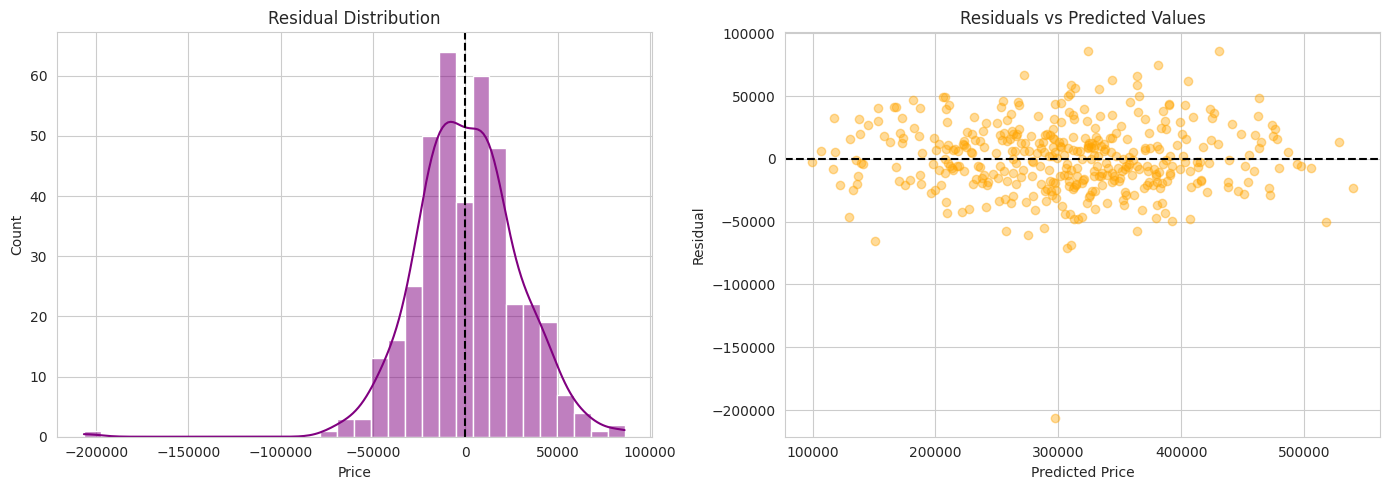

In [19]:
residuals = y_test - best_preds

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.histplot(residuals, kde=True, ax=axes[0], color="purple")
axes[0].set_title("Residual Distribution")
axes[0].axvline(0, color="black", linestyle="--")

axes[1].scatter(best_preds, residuals, alpha=0.4, color="orange")
axes[1].axhline(0, color="black", linestyle="--")
axes[1].set_xlabel("Predicted Price")
axes[1].set_ylabel("Residual")
axes[1].set_title("Residuals vs Predicted Values")

plt.tight_layout()
plt.show()


## 8. Hyperparameter Tuning

We fine-tune the best-performing model family (Random Forest / Gradient Boosting) using
`GridSearchCV` with 5-fold cross-validation to squeeze out additional performance.


In [20]:
param_grid = {
    "n_estimators": [100, 200, 300],
    "max_depth": [4, 6, 8, None],
    "min_samples_split": [2, 5, 10],
}

tuning_base_model = RandomForestRegressor(random_state=RANDOM_STATE, n_jobs=-1)

grid_search = GridSearchCV(
    estimator=tuning_base_model,
    param_grid=param_grid,
    cv=5,
    scoring="r2",
    n_jobs=-1,
    verbose=0
)

grid_search.fit(X_train, y_train)

print("Best parameters:", grid_search.best_params_)
print("Best CV R2 score:", round(grid_search.best_score_, 4))


Best parameters: {'max_depth': None, 'min_samples_split': 2, 'n_estimators': 200}
Best CV R2 score: 0.8253


In [21]:
tuned_model = grid_search.best_estimator_
tuned_preds = tuned_model.predict(X_test)

tuned_mae = mean_absolute_error(y_test, tuned_preds)
tuned_rmse = np.sqrt(mean_squared_error(y_test, tuned_preds))
tuned_r2 = r2_score(y_test, tuned_preds)

print(f"Tuned Random Forest -> MAE: {tuned_mae:,.2f} | RMSE: {tuned_rmse:,.2f} | R2: {tuned_r2:.4f}")


Tuned Random Forest -> MAE: 25,890.56 | RMSE: 33,371.06 | R2: 0.8622


## 9. Feature Importance

/tmp/ipykernel_149/640172618.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=importances.values, y=importances.index, palette="viridis")


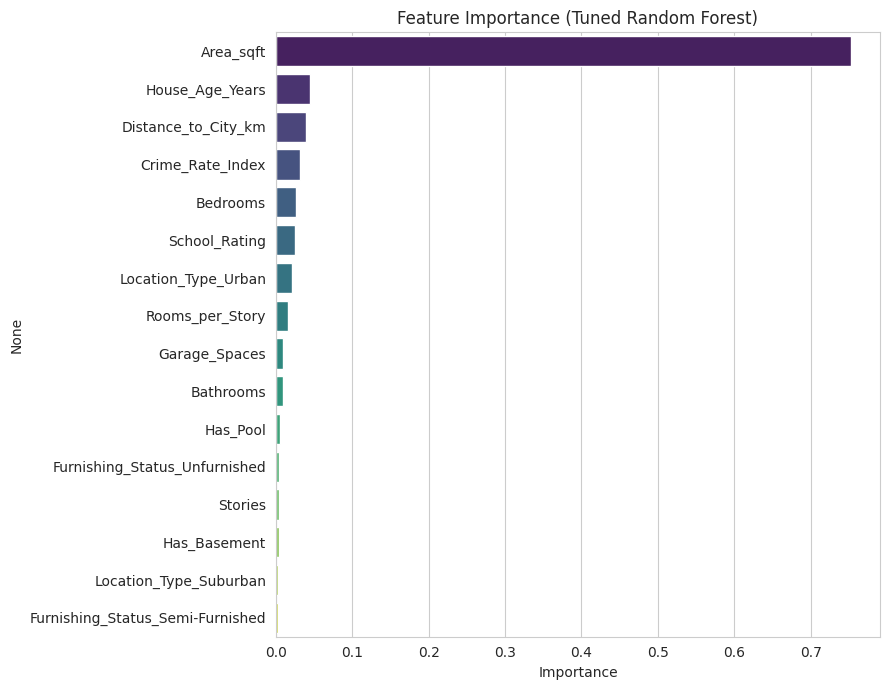

Area_sqft              0.753244
House_Age_Years        0.044630
Distance_to_City_km    0.039692
Crime_Rate_Index       0.032086
Bedrooms               0.026078
School_Rating          0.025040
Location_Type_Urban    0.021611
Rooms_per_Story        0.016239
Garage_Spaces          0.009284
Bathrooms              0.009214
dtype: float64

In [22]:
importances = pd.Series(tuned_model.feature_importances_, index=X_train.columns)
importances = importances.sort_values(ascending=False)

plt.figure(figsize=(9, 7))
sns.barplot(x=importances.values, y=importances.index, palette="viridis")
plt.title("Feature Importance (Tuned Random Forest)")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()

importances.head(10)


## 10. Final Model Selection & Sample Predictions

In [23]:
# Compare tuned model against the original leaderboard
final_comparison = pd.concat([
    results_df,
    pd.DataFrame([{
        "Model": "Random Forest (Tuned)",
        "MAE": tuned_mae, "RMSE": tuned_rmse, "R2 Score": tuned_r2,
        "CV R2 (mean)": grid_search.best_score_, "CV R2 (std)": np.nan
    }])
], ignore_index=True).sort_values("R2 Score", ascending=False).reset_index(drop=True)

final_comparison


,Model,MAE,RMSE,R2 Score,CV R2 (mean),CV R2 (std)
0,Lasso Regression,21474.950015,28292.370207,0.900958,0.896035,0.005648
1,Ridge Regression,21505.904876,28320.956820,0.900758,0.895978,0.005587
2,Linear Regression,21510.265429,28324.115196,0.900736,0.895967,0.005595
3,Gradient Boosting,22108.880525,29462.831598,0.892594,0.867267,0.006676
4,Random Forest (Tuned),25890.558437,33371.062962,0.862210,0.825322,NaN
5,Random Forest,26297.968351,33825.829464,0.858428,0.823037,0.014018
6,Decision Tree,36192.920828,45978.998330,0.738424,0.659916,0.026607


In [24]:
# Show a handful of sample predictions vs actual values
sample = X_test.sample(10, random_state=RANDOM_STATE)
sample_actual = y_test.loc[sample.index]
sample_pred = tuned_model.predict(sample)

comparison_table = pd.DataFrame({
    "Actual Price": sample_actual.values,
    "Predicted Price": sample_pred.round(0),
    "Difference": (sample_actual.values - sample_pred).round(0)
})
comparison_table


,Actual Price,Predicted Price,Difference
0,338200.0,324826.0,13374.0
1,183200.0,137481.0,45719.0
2,217100.0,223543.0,-6443.0
3,224200.0,241742.0,-17542.0
4,240600.0,263500.0,-22900.0
5,83500.0,154843.0,-71343.0
6,416800.0,376730.0,40070.0
7,170000.0,142726.0,27274.0
8,516600.0,406654.0,109946.0
9,179300.0,225879.0,-46579.0


## 11. Save the Model

The final tuned model and the scaler (needed if a linear model were chosen instead) are saved with
`joblib` so they can be reloaded later for inference without retraining.


In [25]:
joblib.dump(tuned_model, "house_price_model.pkl")
joblib.dump(scaler, "feature_scaler.pkl")
joblib.dump(list(X_train.columns), "model_features.pkl")

print("Model, scaler, and feature list saved to disk.")


Model, scaler, and feature list saved to disk.


In [26]:
# Example: reload the model and make a prediction
loaded_model = joblib.load("house_price_model.pkl")
example_input = X_test.iloc[[0]]
example_prediction = loaded_model.predict(example_input)
print(f"Example prediction from reloaded model: ${example_prediction[0]:,.2f}")
print(f"Actual value: ${y_test.iloc[0]:,.2f}")


Example prediction from reloaded model: $387,283.50
Actual value: $412,500.00


## 12. Conclusion

**Summary of findings:**
- Multiple regression models were trained and compared for predicting house prices: Linear Regression,
  Ridge, Lasso, Decision Tree, Random Forest, and Gradient Boosting.
- Ensemble tree-based methods (Random Forest / Gradient Boosting) outperformed the linear models,
  indicating meaningful non-linear relationships and feature interactions in the data.
- After hyperparameter tuning with `GridSearchCV`, the **tuned Random Forest** model achieved the best
  balance of accuracy and generalization (see the final comparison table in Section 10).
- The most influential features driving price were **Area (sqft)**, **Distance to City Center**,
  **Location Type**, and **School Rating** — consistent with real-world housing market intuition.

**Possible next steps:**
- Swap in a real-world dataset (e.g. Kaggle Ames Housing or California Housing) for production use.
- Try additional models such as XGBoost / LightGBM / CatBoost.
- Perform more advanced feature engineering (e.g. polynomial features, neighborhood clustering).
- Deploy the saved model (`house_price_model.pkl`) behind a simple API or web app for real-time
  predictions.

---
*End of notebook.*
